In [4]:
import astropy.io.fits as pf
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import math
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
import os
import subprocess
import importlib as imp
import copy
import scipy.stats
from matplotlib.pyplot import cm
from scipy.stats import kde
import figure_subroutines as subs
from astropy import units as u
from astropy.coordinates import SkyCoord
from pylab import *
from matplotlib import ticker

In [5]:
fieldnames = ['ob02','ob03','ob04','ob05',
              'ob08','ob09','ob10','ob11',
              'ob12','ob13','ob14','ob15',
              'ob16','ob17','sn01','sn02',
              'sn03','rr22']
numname = np.size(fieldnames)

fieldandband = []

for i in range(0,numname):
    fieldandband.append(fieldnames[i]+'_aq')
    fieldandband.append(fieldnames[i]+'_au')
    fieldandband.append(fieldnames[i]+'_bq')
    fieldandband.append(fieldnames[i]+'_bu')
    fieldandband.append(fieldnames[i]+'_cq')
    fieldandband.append(fieldnames[i]+'_cu')
    fieldandband.append(fieldnames[i]+'_dq')
    fieldandband.append(fieldnames[i]+'_du')

print(fieldandband)

numfields = np.size(fieldandband)
print(numfields)


['ob02_aq', 'ob02_au', 'ob02_bq', 'ob02_bu', 'ob02_cq', 'ob02_cu', 'ob02_dq', 'ob02_du', 'ob03_aq', 'ob03_au', 'ob03_bq', 'ob03_bu', 'ob03_cq', 'ob03_cu', 'ob03_dq', 'ob03_du', 'ob04_aq', 'ob04_au', 'ob04_bq', 'ob04_bu', 'ob04_cq', 'ob04_cu', 'ob04_dq', 'ob04_du', 'ob05_aq', 'ob05_au', 'ob05_bq', 'ob05_bu', 'ob05_cq', 'ob05_cu', 'ob05_dq', 'ob05_du', 'ob08_aq', 'ob08_au', 'ob08_bq', 'ob08_bu', 'ob08_cq', 'ob08_cu', 'ob08_dq', 'ob08_du', 'ob09_aq', 'ob09_au', 'ob09_bq', 'ob09_bu', 'ob09_cq', 'ob09_cu', 'ob09_dq', 'ob09_du', 'ob10_aq', 'ob10_au', 'ob10_bq', 'ob10_bu', 'ob10_cq', 'ob10_cu', 'ob10_dq', 'ob10_du', 'ob11_aq', 'ob11_au', 'ob11_bq', 'ob11_bu', 'ob11_cq', 'ob11_cu', 'ob11_dq', 'ob11_du', 'ob12_aq', 'ob12_au', 'ob12_bq', 'ob12_bu', 'ob12_cq', 'ob12_cu', 'ob12_dq', 'ob12_du', 'ob13_aq', 'ob13_au', 'ob13_bq', 'ob13_bu', 'ob13_cq', 'ob13_cu', 'ob13_dq', 'ob13_du', 'ob14_aq', 'ob14_au', 'ob14_bq', 'ob14_bu', 'ob14_cq', 'ob14_cu', 'ob14_dq', 'ob14_du', 'ob15_aq', 'ob15_au', 'ob15_bq'

In [6]:
C_initial_files = []
C_feather_files = []
G_initial_files = []
G_matched_files = []
G_feather_files = []
Gu_files = []
Gv_files = []
Cu_files = []
Cv_files = []
uv_delt = np.zeros([numfields])

for i in range(0,numfields):
    
    step_files = ['../../GMIMS_CGPS_OB_RW/THESIS_pics/G_initial_uv_'+fieldandband[i]+'.fits',
                  '../../GMIMS_CGPS_OB_RW/THESIS_pics/G_matched_uv_'+fieldandband[i]+'.fits',
                  '../../GMIMS_CGPS_OB_RW/THESIS_pics/G_feather_uv_'+fieldandband[i]+'.fits',
                  '../../GMIMS_CGPS_OB_RW/THESIS_pics/C_initial_uv_'+fieldandband[i]+'.fits',
                  '../../GMIMS_CGPS_OB_RW/THESIS_pics/C_feather_uv_'+fieldandband[i]+'.fits']

    field = fits.open(step_files[3])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    C_initial_files.append(data)
    
    field = fits.open(step_files[4])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    C_feather_files.append(data)

    u,v = subs.make_axis_lists_2D(hdr)
    Cu_files.append(u)
    Cv_files.append(v)
    
    field = fits.open(step_files[0])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    G_initial_files.append(data)
    
    field = fits.open(step_files[1])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    G_matched_files.append(data)
    
    field = fits.open(step_files[2])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    G_feather_files.append(data)
    
    u,v = subs.make_axis_lists_2D(hdr)
    Gu_files.append(u)
    Gv_files.append(v)
    
    
    
    uv_delt[i] = hdr['CDELT2']
    print(i,fieldandband[i],uv_delt[i])

(0, 'ob02_aq', 2.1456778)
(1, 'ob02_au', 2.1456778)
(2, 'ob02_bq', 2.1352081)
(3, 'ob02_bu', 2.1352081)
(4, 'ob02_cq', 2.1148684)
(5, 'ob02_cu', 2.1148684)
(6, 'ob02_dq', 2.1046965)
(7, 'ob02_du', 2.1046965)
(8, 'ob03_aq', 2.1456778)
(9, 'ob03_au', 2.1456778)
(10, 'ob03_bq', 2.1352081)
(11, 'ob03_bu', 2.1352081)
(12, 'ob03_cq', 2.1148684)
(13, 'ob03_cu', 2.1148684)
(14, 'ob03_dq', 2.1046965)
(15, 'ob03_du', 2.1046965)
(16, 'ob04_aq', 2.1456778)
(17, 'ob04_au', 2.1456778)
(18, 'ob04_bq', 2.1352081)
(19, 'ob04_bu', 2.1352081)
(20, 'ob04_cq', 2.1148684)
(21, 'ob04_cu', 2.1148684)
(22, 'ob04_dq', 2.1046965)
(23, 'ob04_du', 2.1046965)
(24, 'ob05_aq', 2.1456778)
(25, 'ob05_au', 2.1456778)
(26, 'ob05_bq', 2.1352081)
(27, 'ob05_bu', 2.1352081)
(28, 'ob05_cq', 2.1148684)
(29, 'ob05_cu', 2.1148684)
(30, 'ob05_dq', 2.1046965)
(31, 'ob05_du', 2.1046965)
(32, 'ob08_aq', 2.1456778)
(33, 'ob08_au', 2.1456778)
(34, 'ob08_bq', 2.1352081)
(35, 'ob08_bu', 2.1352081)
(36, 'ob08_cq', 2.1148684)
(37, 'ob08_

In [7]:
ampl_G_initial = []
ampl_G_match = []
ampl_G_feath = []
ampl_C_initial = []
ampl_C_feath = []

radius_G_fields = []
radius_C_fields = []

for k in range(0,numfields):

    #=============== SA initial ======================================
    ampl_G_initial.append(G_initial_files[k][1:1024,0:513])
    #print(ampl_G_initial[i][0,0])
    #print(ampl_G_initial[i][511,0])
    #print(ampl_G_initial[i][1022,0])
    #print(ampl_G_initial[i].shape)
    #print('')
    #=============== SA matched ======================================
    ampl_G_match.append(G_matched_files[k][1:1024,0:513])
    #print(ampl_G_match[i][0,0])
    #print(ampl_G_match[i][511,0])
    #print(ampl_G_match[i][1022,0])
    #print(ampl_G_match[i].shape)
    #print('')
    #=============== SA feathered ======================================
    ampl_G_feath.append(G_feather_files[k][1:1024,0:513])
    #print(ampl_G_feath[i][0,0])
    #print(ampl_G_feath[i][511,0])
    #print(ampl_G_feath[i][1022,0])
    #print(ampl_G_feath[i].shape)
    #print('')
    #=============== ST initial ======================================
    ampl_C_initial.append(C_initial_files[k][1:1024,0:513])
    #print(ampl_C_initial[i][0,0])
    #print(ampl_C_initial[i][511,0])
    #print(ampl_C_initial[i][1022,0])
    #print(ampl_C_initial[i].shape)
    #print('')
    #=============== ST feathered ======================================
    ampl_C_feath.append(C_feather_files[k][1:1024,0:513])
    #print(ampl_C_feath[i][0,0])
    #print(ampl_C_feath[i][511,0])
    #print(ampl_C_feath[i][1022,0])
    #print(ampl_C_feath[i].shape)
    #print('')

    radius_C = np.zeros([1023,513])
    radius_G = np.zeros([1023,513])
    
    u_G = np.flip(Gu_files[k][1:514],axis=0)
    v_G = Gv_files[k][1:1024]
    u_C = np.flip(Cu_files[k][1:514],axis=0)
    v_C = Cv_files[k][1:1024]
    print(k)
    #print(np.min(u_C), np.max(u_C), u_C.shape)
    #print(np.min(v_C), np.max(v_C), v_C.shape)
    #print(np.min(u_G), np.max(u_G), u_G.shape)
    #print(np.min(v_G), np.max(v_G), v_G.shape)
    #print('')
    
    for i in range(0,513):
        for j in range(0,1023):
            radius_G[j,i] = np.sqrt((u_G[i])**2+(v_G[j])**2)
            radius_C[j,i] = np.sqrt((u_C[i])**2+(v_C[j])**2)
    
    radius_C_fields.append(radius_C)
    radius_G_fields.append(radius_G)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143


In [8]:
SA_orig_samples = np.zeros([numfields,120])
SA_match_samples = np.zeros([numfields,120])
SA_feath_samples = np.zeros([numfields,120])
ST_orig_samples = np.zeros([numfields,120])
ST_feath_samples = np.zeros([numfields,120])
rad_samples = np.zeros([numfields,120])

for j in range(0,numfields):
    print(j)
    rad_samples[j,:] = np.unique(radius_C_fields[j])[0:120]
    for i in range(0,120):
        wx = np.where((radius_C_fields[j]==rad_samples[j,i]))[1]
        wy = np.where((radius_C_fields[j]==rad_samples[j,i]))[0]
        SA_orig_samples[j,i] = np.mean(ampl_G_initial[j][wy,wx])
        SA_match_samples[j,i] = np.mean(ampl_G_match[j][wy,wx])
        SA_feath_samples[j,i] = np.mean(ampl_G_feath[j][wy,wx])
        ST_orig_samples[j,i] = np.mean(ampl_C_initial[j][wy,wx])
        ST_feath_samples[j,i] = np.mean(ampl_C_feath[j][wy,wx])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143


In [ ]:
j = 65 # OB12 AU

fs=22
lw = 2

axs = ['ax1','ax2','ax3']

fig = plt.figure(figsize=(17,15))
plt.subplots_adjust(top = 0.98, bottom = 0.06, right = 0.98, left = 0.08, hspace=0.1)

axs[0] = fig.add_subplot(311)
axs[0].scatter(radius_C_fields[j],ampl_C_initial[j],s=60,label='ST: original visibilities')
axs[0].scatter(radius_G_fields[j],ampl_G_initial[j],s=50,label='SA: visibilities after initial taper')
axs[0].plot(rad_samples[j,:],ST_orig_samples[j],color='blue',linewidth=lw,label='ST: mean')
axs[0].plot(rad_samples[j,:],SA_orig_samples[j],color='red',linewidth=lw,label='SA: mean')
handles,labels = axs[0].get_legend_handles_labels()
order = [2,0,3,1]
axs[0].set_ylim(0,4000)
axs[0].legend([handles[idx] for idx in order], [labels[idx] for idx in order],fontsize=fs)

axs[1] = fig.add_subplot(312)
axs[1].scatter(radius_C_fields[j],ampl_C_initial[j],s=60,label='ST: original visibilities')
axs[1].scatter(radius_G_fields[j],ampl_G_match[j],s=50,label='SA: visibilities matched to ST beam')
axs[1].plot(rad_samples[j,:],ST_orig_samples[j],color='blue',linewidth=lw,label='ST: mean')
axs[1].plot(rad_samples[j,:],SA_match_samples[j],color='red',linewidth=lw,label='SA: mean')
axs[1].set_ylim(0,2000)
handles,labels = axs[1].get_legend_handles_labels()
order = [2,0,3,1]
axs[1].legend([handles[idx] for idx in order], [labels[idx] for idx in order],fontsize=fs)

axs[2] = fig.add_subplot(313)
axs[2].set_xlabel('$\sqrt{u^2+v^2}$ (m)',fontsize=fs)
axs[2].scatter(radius_C_fields[j],ampl_C_feath[j],s=60,label='ST: visibilities feathered')
axs[2].scatter(radius_G_fields[j],ampl_G_feath[j],s=50,label='SA: visibilities feathered')
axs[2].plot(rad_samples[j,:],ST_feath_samples[j],color='blue',linewidth=lw,label='ST: mean')
axs[2].plot(rad_samples[j,:],SA_feath_samples[j],color='red',linewidth=lw,label='SA: mean')
axs[2].set_ylim(0,2000)
handles,labels = axs[2].get_legend_handles_labels()
order = [2,0,3,1]
axs[2].legend([handles[idx] for idx in order], [labels[idx] for idx in order],fontsize=fs)

for i in range(0,3):
    axs[i].tick_params(axis="x", labelsize=fs)
    axs[i].tick_params(axis="y", labelsize=fs)
    axs[i].set_xlim(0,50)
    axs[i].set_ylabel('PI (K - uv-plane equiv.)',fontsize=fs)
    axs[i].plot([12.858,12.858],[0,80000],color='black',linestyle='dashed')
    axs[i].plot([17.144,17.144,],[0,80000],color='black',linestyle='dashed')
    axs[i].grid()
    axs[i].set_xticks([0,5,10,15,20,25,30,35,40,45,50])
    #axs[i].set_ticklabels(fontsize=fs)

#plt.savefig('FIGURES/CGPS_GMIMS_UV_radial_good.pdf')

In [9]:
ratioavg = np.zeros([numfields])

for j in range(0,numfields):
    
    woverlap = np.where((rad_samples[j,:]<16.8) & (rad_samples[j,:]>13.2))
    C_test = ST_orig_samples[j][woverlap]
    G_test = SA_match_samples[j][woverlap]
    #print(C_test)
    #print(G_test)
    avrg = (G_test+C_test)/2.
    #print(avrg)
    ratio = G_test/C_test
    ratioavg[j] = np.mean(ratio)
    #print(j,fieldandband[j],ratioavg[j])
    print(ratioavg[j])

3.0271568798200947
1.859671712299954
2.6195911147839093
1.6372151100319208
3.136641215732363
2.5269091687165752
2.291312437982945
1.921667082912003
1.73579754788644
1.1154643002868325
1.6175424642446565
1.0299487156204392
0.9614385596936744
1.3882086705193633
0.7815544621206579
0.6779896525381168
2.6310333334911697
1.0215198642117502
2.2892056845808275
1.0728246520500448
1.3419040301494944
1.1338219502354416
1.4426942725884542
0.971173651893589
1.1425467740043573
0.6752894754401341
1.0899958192956432
0.5363931721983258
0.9056665878601973
0.6603267454910551
1.237045133092527
0.7113483935101335
2.931890360254768
4.1202080670748105
1.6774063440991924
2.314318094762889
1.0095276880071884
1.5763264680995415
0.8403436635186322
1.6172487119023404
1.429374874599875
1.7861502436918808
1.2423041221684836
1.6085316110296177
0.9234171388326462
2.502019091732115
0.8370556861924673
1.7793086757275396
1.9502566976029858
1.266774369382241
0.9417995930347556
1.3792709095299944
0.9408423944275357
1.4063

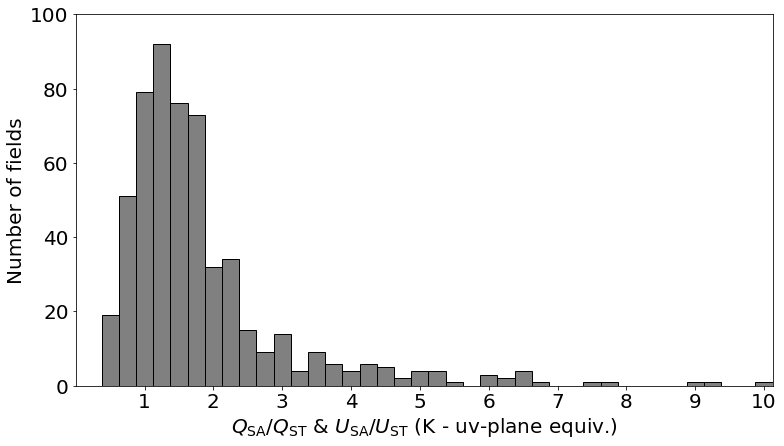

In [10]:
ratios = np.zeros([568])
f = open("CGPS_GMIMS_uv_ratios_RW.txt", "r")
i=0
for x in f:
    #print(x) 
    ratios[i] = x
    i=i+1

ratios = np.asarray(ratios)
#print(ratios)

fs = 20

fig = plt.figure(figsize=(11,6))
plt.subplots_adjust(top = 0.98, bottom = 0.12, right = 0.98, left = 0.1)
axs = fig.add_subplot(111)
axs.hist(ratios,bins=40,range=(0.125,10.125),color='Grey', edgecolor='black', linewidth=1.)
axs.set_xlabel('$Q_{\mathrm{SA}}/Q_{\mathrm{ST}}$ & $U_{\mathrm{SA}}/U_{\mathrm{ST}}$ (K - uv-plane equiv.)',fontsize=fs)
#axs.set_xlabel(r'$\frac{Q,U_{\mathrm{GMIMS}}}{Q,U_{\mathrm{ST}}}$ (uv-plane equiv.)',fontsize=fs)
axs.tick_params(axis="x", labelsize=fs)
axs.tick_params(axis="y", labelsize=fs)
axs.set_xlim(0,10.125)
axs.set_ylim(0,100)
axs.set_ylabel('Number of fields',fontsize=fs)
#axs.grid()
axs.set_xticks([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0])
#plt.savefig('FIGURES/uv_plane_ratio_histogram_REWORK.pdf')

(0, 15)

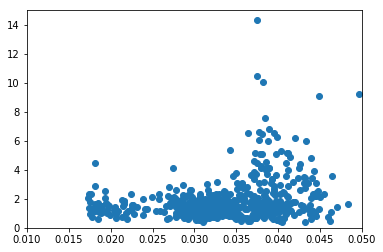

In [16]:
C_PI = np.zeros([568])
G_PI = np.zeros([568])

f = open("CGPS_PI.txt", "r")
i=0
for x in f:
    #print(x) 
    C_PI[i] = x
    i=i+1
    
f = open("GMIMS_PI.txt", "r")
i=0
for x in f:
    #print(x) 
    G_PI[i] = x
    i=i+1

C_PI = np.asarray(C_PI)
G_PI = np.asarray(G_PI)

plt.scatter(C_PI,ratios)
plt.xlim(0.01,0.05)
plt.ylim(0,15)


(0, 15)

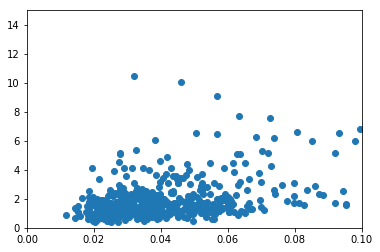

In [18]:
plt.scatter(G_PI,ratios)

plt.xlim(0.0,0.1)
plt.ylim(0,15)

(array([  1,   7,  84,  86, 136, 139, 141, 143, 144, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 163, 165, 167, 176, 233, 424, 427,
       429]),)


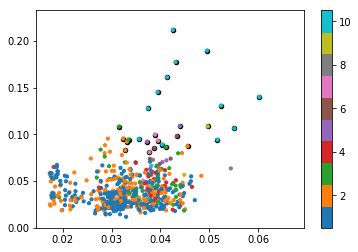

In [34]:
wbig = np.where((C_PI>0.03) & (G_PI>0.08))
print(wbig)

plt.scatter(C_PI[wbig],G_PI[wbig],c='black',s=20)
plt.scatter(C_PI,G_PI,c=ratios,cmap=cm.tab10,vmin=0.5,vmax=10.5,s=10)
plt.colorbar()

OLD CODE:

In [35]:
rad_samples = np.linspace(0,90,31)
rad_samples_centre = np.linspace(1.5,88.5,30)
print(rad_samples)
print(rad_samples_centre)
print('')
SA_orig_samples = np.zeros([numfields,30])
SA_match_samples = np.zeros([numfields,30])
SA_feath_samples = np.zeros([numfields,30])
ST_orig_samples = np.zeros([numfields,30])
ST_feath_samples = np.zeros([numfields,30])

for j in range(0,numfields):
    for i in range(0,np.size(rad_samples)-1):
        wx = np.where((radius_C_fields[j]>=rad_samples[i]) & (radius_C_fields[j]<rad_samples[i+1]))[1]
        wy = np.where((radius_C_fields[j]>=rad_samples[i]) & (radius_C_fields[j]<rad_samples[i+1]))[0]
        SA_orig_samples[j,i] = np.mean(ampl_G_initial[j][wy,wx])
        SA_match_samples[j,i] = np.mean(ampl_G_match[j][wy,wx])
        SA_feath_samples[j,i] = np.mean(ampl_G_feath[j][wy,wx])
        ST_orig_samples[j,i] = np.mean(ampl_C_initial[j][wy,wx])
        ST_feath_samples[j,i] = np.mean(ampl_C_feath[j][wy,wx])

[ 0.  3.  6.  9. 12. 15. 18. 21. 24. 27. 30. 33. 36. 39. 42. 45. 48. 51.
 54. 57. 60. 63. 66. 69. 72. 75. 78. 81. 84. 87. 90.]
[ 1.5  4.5  7.5 10.5 13.5 16.5 19.5 22.5 25.5 28.5 31.5 34.5 37.5 40.5
 43.5 46.5 49.5 52.5 55.5 58.5 61.5 64.5 67.5 70.5 73.5 76.5 79.5 82.5
 85.5 88.5]



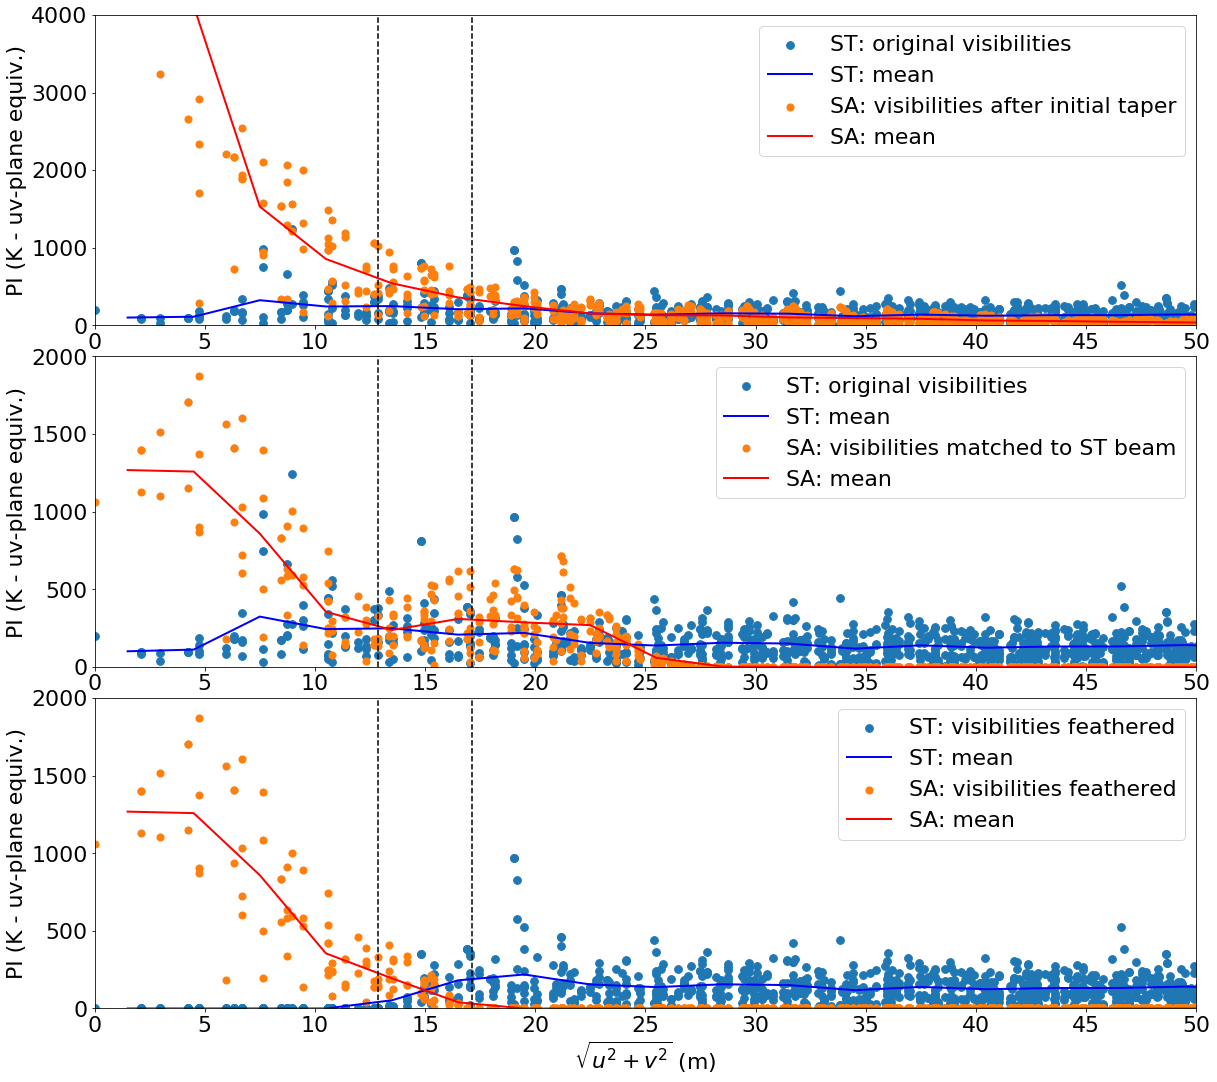

In [43]:
j = 69 # pick which field to plot

fs=22
lw = 2

axs = ['ax1','ax2','ax3']

fig = plt.figure(figsize=(17,15))
plt.subplots_adjust(top = 0.98, bottom = 0.06, right = 0.98, left = 0.08, hspace=0.1)

axs[0] = fig.add_subplot(311)
axs[0].scatter(radius_C_fields[j],ampl_C_initial[j],s=60,label='ST: original visibilities')
axs[0].scatter(radius_G_fields[j],ampl_G_initial[j],s=50,label='SA: visibilities after initial taper')
axs[0].plot(rad_samples_centre,ST_orig_samples[j],color='blue',linewidth=lw,label='ST: mean')
axs[0].plot(rad_samples_centre,SA_orig_samples[j],color='red',linewidth=lw,label='SA: mean')
handles,labels = axs[0].get_legend_handles_labels()
order = [2,0,3,1]
axs[0].set_ylim(0,4000)
axs[0].legend([handles[idx] for idx in order], [labels[idx] for idx in order],fontsize=fs)

axs[1] = fig.add_subplot(312)
axs[1].scatter(radius_C_fields[j],ampl_C_initial[j],s=60,label='ST: original visibilities')
axs[1].scatter(radius_G_fields[j],ampl_G_match[j],s=50,label='SA: visibilities matched to ST beam')
axs[1].plot(rad_samples_centre,ST_orig_samples[j],color='blue',linewidth=lw,label='ST: mean')
axs[1].plot(rad_samples_centre,SA_match_samples[j],color='red',linewidth=lw,label='SA: mean')
axs[1].set_ylim(0,2000)
handles,labels = axs[1].get_legend_handles_labels()
order = [2,0,3,1]
axs[1].legend([handles[idx] for idx in order], [labels[idx] for idx in order],fontsize=fs)

axs[2] = fig.add_subplot(313)
axs[2].set_xlabel('$\sqrt{u^2+v^2}$ (m)',fontsize=fs)
axs[2].scatter(radius_C_fields[j],ampl_C_feath[j],s=60,label='ST: visibilities feathered')
axs[2].scatter(radius_G_fields[j],ampl_G_feath[j],s=50,label='SA: visibilities feathered')
axs[2].plot(rad_samples_centre,ST_feath_samples[j],color='blue',linewidth=lw,label='ST: mean')
axs[2].plot(rad_samples_centre,SA_feath_samples[j],color='red',linewidth=lw,label='SA: mean')
axs[2].set_ylim(0,2000)
handles,labels = axs[2].get_legend_handles_labels()
order = [2,0,3,1]
axs[2].legend([handles[idx] for idx in order], [labels[idx] for idx in order],fontsize=fs)

for i in range(0,3):
    axs[i].tick_params(axis="x", labelsize=fs)
    axs[i].tick_params(axis="y", labelsize=fs)
    axs[i].set_xlim(0,50)
    axs[i].set_ylabel('PI (K - uv-plane equiv.)',fontsize=fs)
    axs[i].plot([12.858,12.858],[0,80000],color='black',linestyle='dashed')
    axs[i].plot([17.144,17.144,],[0,80000],color='black',linestyle='dashed')
    axs[i].set_xticks([0,5,10,15,20,25,30,35,40,45,50])
    #axs[i].set_ticklabels(fontsize=fs)

plt.savefig('FIGURES/combining_radial_plots.pdf')

In [ ]:
percdiffavg = np.zeros([numfields])

for j in range(0,numfields):
    
    woverlap = np.where((rad_samples_centre<=17.144) & (rad_samples_centre>=12.858))
    C_test = ST_orig_samples[j][woverlap]
    G_test = SA_match_samples[j][woverlap]
    #print(C_test)
    #print(G_test)
    avrg = (G_test+C_test)/2.
    #print(avrg)
    percdiff = 100.*abs(G_test-C_test)/avrg
    percdiffavg[j] = np.mean(percdiff)
    print(j,percdiff,percdiffavg[j])

In [ ]:
plt.hist(percdiffavg, bins=15)  


In [ ]:
ratioavg = np.zeros([numfields])

for j in range(0,numfields):
    
    woverlap = np.where((rad_samples_centre<=17.144) & (rad_samples_centre>=12.858))
    C_test = ST_orig_samples[j][woverlap]
    G_test = SA_match_samples[j][woverlap]
    #print(C_test)
    #print(G_test)
    avrg = (G_test+C_test)/2.
    #print(avrg)
    ratio = G_test/C_test
    ratioavg[j] = np.mean(ratio)
    print(j,ratio,ratioavg[j])

In [ ]:
plt.hist(ratioavg, bins=10)  